## Gerrychain

In [ ]:
import matplotlib.pyplot as plt
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial

In [ ]:
id_graph = Graph.from_file('./ID/ID.shp')


/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/gerrychain/graph/graph.py:457: UserWarning: NA values found in column G18GOVDJOR!
  warnings.warn("NA values found in column {}!".format(column))
/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/gerrychain/graph/graph.py:457: UserWarning: NA values found in column G18GOVRLIT!
  warnings.warn("NA values found in column {}!".format(column))


/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 5000/5000 [00:09<00:00, 544.51it/s]


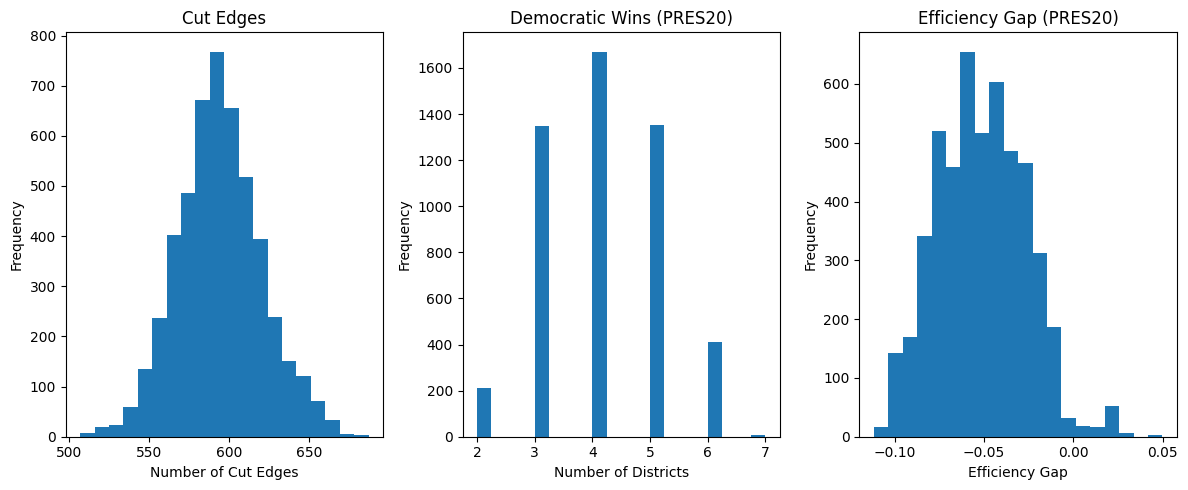

In [ ]:
total_steps_in_run = 5000

elections = [
    Election('PRES20', {'Democratic': 'G20PREDBID', 'Republican': 'G20PRERTRU'}),
    Election('GOV18',{'Democratic': 'G18GOVDJOR', 'Republican': 'G18GOVRLIT'}),
]

my_updaters = {
    'population': updaters.Tally('TOTPOP', alias='population'),
    'cut_edges': cut_edges,
    'VAP': updaters.Tally('VAP', alias='VAP'),
}

election_updaters = {election.name: election for election in elections}
my_updaters.update(election_updaters)

initial_partition = Partition(
    id_graph,
    assignment='SDIST',
    updaters=my_updaters
)

ideal_population = sum(initial_partition['population'].values()) / len(initial_partition)

proposal = partial(recom,                                                                                    
                    pop_col="TOTPOP",                                                                         
                    pop_target=ideal_population,                                                              
                    epsilon=0.5,                                                                           
                    node_repeats=2                                                                            
                )

compactness_bound = constraints.UpperBound(
    lambda p: len(p['cut_edges']),
    2 * len(initial_partition['cut_edges'])
)

pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.5)

chain = MarkovChain(
    proposal=proposal,
    constraints=[pop_constraint, compactness_bound],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=total_steps_in_run
)

cut_edges_data = []
dem_wins_data = []
eg_data = []

for partition in chain.with_progress_bar():
    cut_edges_data.append(len(partition['cut_edges']))
    dem_wins_data.append(partition['PRES20'].wins('Democratic'))
    eg_data.append(partition['PRES20'].efficiency_gap()) 

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].hist(cut_edges_data, bins=20)
axes[0].set_title('Cut Edges')
axes[0].set_xlabel('Number of Cut Edges')
axes[0].set_ylabel('Frequency')

axes[1].hist(dem_wins_data, bins=20)
axes[1].set_title('Democratic Wins (PRES20)')
axes[1].set_xlabel('Number of Districts')
axes[1].set_ylabel('Frequency')

axes[2].hist(eg_data, bins=20)
axes[2].set_title('Efficiency Gap (PRES20)')                                                                                                                                                                                      
axes[2].set_xlabel('Efficiency Gap')                     
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('id_histograms.png')
plt.show()

In [ ]:
end_time = time.time()
print('The time of execution of above program is :',
      (end_time-start_time)/60, 'mins')

The time of execution of above program is : 28.235850699742635 mins
